# AQH 2026 — Track 2: The 64-Copy Problem
## FINAL V9.2 — Shot-Consistent Quantum Architecture Search + Incumbent V8.1 Comparison

### Why V9.2 exists
V9 used exact expectation-value features for fitting and different nonlinear single-shot summaries at finite-copy inference. That created a train/inference feature-distribution mismatch and produced misleading flat low-copy curves.

**V9.2 removes that mismatch completely.**

### Quantum candidates
1. **INCUMBENT — exact V8.1 runtime** when its frozen package is attached to Kaggle.
2. **M0 — V8.1 Bell-circuit ablation**, trained/evaluated with the new shot-consistent protocol.
3. **M1 — 3-parameter Generalized Bell-QML.**
4. **M2 — QCNN-inspired shared local variational circuit.**

### Core methodological rule
> The model is trained on the same finite-copy feature estimator that it receives at inference.

No classifier is trained on `f(E[Z])` and then evaluated on `E[f(Z_shot)]`.

### Hidden-set rule
Hidden organizer labels are **final audit only**. They are never used for architecture selection, parameter search, head fitting, thresholds, or prototype calibration.

## 0. Competition compliance lock

| Requirement | V9.2 implementation |
|---|---|
| At most 64 copies per state | Every episode has an explicit budget |
| Scored window | 4, 8, 16 |
| Mandatory reported curve | 4, 8, 16, 32, 64 |
| Primary model must be QML | Shared trainable parameters are consumed inside circuits acting on the quantum state |
| Trainable quantum parameter count independent of N | All quantum weights are translation-shared |
| Noise robustness | Clean/noisy development sweep + official hidden audit hook |
| Zero-shot size transfer | Same frozen parameters and fixed-dimensional aggregation for every N |
| UNKNOWN rejection | One-class XXZ compatibility, never a fourth XXZ phase |
| Classical baselines | Z-only and X/Z split under identical copy budgets |
| Metrics | Macro-F1, per-class F1, confusion matrices, copy curves, OOD P/R, critical/off-critical and per-size results |
| Incumbent comparison | Exact V8.1 runtime is benchmarked if its package is attached |
| Leakage control | Hidden set cannot participate in winner selection |

### Winner objective
The primary architecture score emphasizes the official starved-copy window:

`0.40 * F1@4 + 0.35 * F1@8 + 0.25 * F1@16`

A tiny complexity penalty is only a tie-breaker.

## 1. Corrected architecture and evidence flow

```text
public quantum states
        │
        ├── fit split
        │     └── finite-copy Monte-Carlo episodes
        │            └── SAME estimator used at inference
        │
        ├── validation split
        │     └── repeated finite-copy episodes at 4/8/16/32/64
        │
        ├─────────────────────────────────────────────────────────────┐
        ▼                                                             ▼
M0 Bell circuit             M1 Generalized Bell             M2 QCNN-inspired
1 shared param              3 shared params                 6 shared params
        │                          │                               │
        └──────────────────────────┴───────────────────────────────┘
                                   │
                        shot-consistent features
                                   │
                         budget-specific phase head
                                   │
                     public low-copy multi-seed score
                                   │
                         deployability / OOD gates
                                   │
                                   ▼
                              winner freeze
                                   │
                 ┌─────────────────┴─────────────────┐
                 ▼                                   ▼
         experimental winner                    exact V8.1
         runtime export                         incumbent package
```

If the original V8.1 package is not attached, V9.2 **does not pretend** that M0 is the exact V8.1 runtime. It reports M0 as a circuit ablation only.

In [1]:
# ============================================================
# 2. Install dependencies
# ============================================================
import sys, subprocess, importlib.util

REQUIRED_PACKAGES = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "pennylane": "pennylane>=0.36",
    "sklearn": "scikit-learn>=1.3",
    "scipy": "scipy>=1.10",
}

missing = [
    pip_name for import_name, pip_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(import_name) is None
]

if missing:
    print("Installing:", missing)
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "--quiet", "--upgrade", *missing
    ])
    print("Installation completed.")
else:
    print("All required dependencies are installed.")

print("Python executable:", sys.executable)

Installing: ['pennylane>=0.36']
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 677.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 50.9 MB/s eta 0:00:00
Installation completed.
Python executable: /usr/bin/python3


In [2]:
# ============================================================
# 3. Imports and environment verification
# ============================================================
from pathlib import Path
import os, sys, json, math, time, csv, hashlib, shutil, zipfile, importlib.util
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml
import sklearn
import scipy

from sklearn.metrics import (
    f1_score, confusion_matrix, precision_score, recall_score,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

print("=" * 72)
print("ENVIRONMENT CHECK")
print("=" * 72)
print("Python       :", sys.version.split()[0])
print("Executable   :", sys.executable)
print("NumPy        :", np.__version__)
print("Pandas       :", pd.__version__)
print("Matplotlib   :", plt.matplotlib.__version__)
print("PennyLane    :", qml.__version__)
print("Scikit-learn :", sklearn.__version__)
print("SciPy        :", scipy.__version__)
print("=" * 72)
print("Environment ready: PASS")

ENVIRONMENT CHECK
Python       : 3.12.13
Executable   : /usr/bin/python3
NumPy        : 2.0.2
Pandas       : 2.3.3
Matplotlib   : 3.10.0
PennyLane    : 0.45.1
Scikit-learn : 1.6.1
SciPy        : 1.16.3
Environment ready: PASS


In [3]:
# ============================================================
# 4. Kaggle-safe path discovery
# ============================================================
KAGGLE_INPUT = Path("/kaggle/input")
ROOT = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()

def find_all(filename):
    root = KAGGLE_INPUT if KAGGLE_INPUT.exists() else Path.cwd()
    return sorted(root.rglob(filename))

def find_file(filename, required=True, prefer_contains=None):
    matches = find_all(filename)
    if prefer_contains:
        preferred = [p for p in matches if prefer_contains.lower() in str(p).lower()]
        if preferred:
            matches = preferred
    if not matches:
        if required:
            raise FileNotFoundError(
                f"Could not find {filename!r} under "
                f"{KAGGLE_INPUT if KAGGLE_INPUT.exists() else Path.cwd()}"
            )
        return None
    if len(matches) > 1:
        print(f"Multiple matches for {filename}:")
        for i, p in enumerate(matches):
            print(f"  [{i}] {p}")
        print("Using:", matches[0])
    return matches[0]

PUBLIC_NPZ = find_file("xxz_public_train.npz", required=True)
PUBLIC_KEY = find_file("train_answer_key.csv", required=False)
ORACLE_PY = find_file("oracle.py", required=False, prefer_contains="participant")
EVALUATE_PY = find_file("evaluate.py", required=False, prefer_contains="participant")

RESULTS_DIR = ROOT / "results_v9_2"
ARTIFACTS_DIR = ROOT / "artifacts_v9_2"
EXPORT_DIR = ROOT / "AQH_Track2_FINAL_SUBMISSION_V9_2"
for p in [RESULTS_DIR, ARTIFACTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

BUDGETS = [4, 8, 16, 32, 64]
SCORED_BUDGETS = [4, 8, 16]
BUDGET_WEIGHTS = {4: 0.40, 8: 0.35, 16: 0.25}

# Development repetition controls.
# Increase these for the final run if Kaggle runtime permits.
TRAIN_EPISODES_PER_STATE = 4
VAL_REPEATS = 8
SEARCH_REPEATS = 4
REPORT_SEEDS = [3, 7, 11, 19, 23]
PRIMARY_SEED = 123

# Keep False until architecture/model freeze.
ENABLE_ORGANIZER_HIDDEN_AUDIT = False

print("ROOT        :", ROOT)
print("PUBLIC_NPZ  :", PUBLIC_NPZ)
print("PUBLIC_KEY  :", PUBLIC_KEY)
print("ORACLE_PY   :", ORACLE_PY)
print("EVALUATE_PY :", EVALUATE_PY)
print("Results     :", RESULTS_DIR)
print("Artifacts   :", ARTIFACTS_DIR)

ROOT        : /kaggle/working
PUBLIC_NPZ  : /kaggle/input/datasets/marwanyasserhassan/participant-kit/AQH_64_Copy_Professional_Solution/xxz_public_train.npz
PUBLIC_KEY  : None
ORACLE_PY   : /kaggle/input/datasets/marwanyasserhassan/participant-kit/AQH_64_Copy_Professional_Solution/oracle.py
EVALUATE_PY : /kaggle/input/datasets/marwanyasserhassan/participant-kit/AQH_64_Copy_Professional_Solution/evaluate.py
Results     : /kaggle/working/results_v9_2
Artifacts   : /kaggle/working/artifacts_v9_2


In [4]:
# ============================================================
# 5. Discover exact frozen V8.1 incumbent package
#    Kaggle Model — recursive robust discovery
# ============================================================

from pathlib import Path

V8_MODEL_ROOT = Path(
    "/kaggle/input/models/marwanyasserhassan/"
    "aqh-track2-final-submission-v8-1/other/default/1"
)


def show_model_files(root: Path):
    """
    Diagnostic listing of all files inside the Kaggle model.
    """
    print("\n" + "=" * 90)
    print("V8.1 KAGGLE MODEL FILE TREE")
    print("=" * 90)

    if not root.exists():
        print("MODEL ROOT DOES NOT EXIST:")
        print(root)
        return

    files = sorted(
        p for p in root.rglob("*")
        if p.is_file()
    )

    if not files:
        print("No files found.")
        return

    for p in files:
        try:
            rel = p.relative_to(root)
        except Exception:
            rel = p
        print(rel)

    print("=" * 90)
    print("Total files:", len(files))


def choose_best_match(matches, preferred_parts=()):
    """
    Choose the most likely intended file if multiple matches exist.
    """
    if not matches:
        return None

    matches = sorted(matches)

    def rank(path):
        s = str(path).lower()

        preferred_score = sum(
            1
            for part in preferred_parts
            if part.lower() in s
        )

        depth = len(path.parts)

        # Higher preferred score first,
        # then shallower path.
        return (
            -preferred_score,
            depth,
            str(path),
        )

    return sorted(
        matches,
        key=rank
    )[0]


def find_v8_incumbent():
    """
    Discover V8.1 runtime files anywhere under the explicit
    Kaggle Model directory.

    We intentionally do NOT assume:
        root/artifacts/model_config.json
        root/artifacts/xxz_bell_prototypes.npz

    because Kaggle Models may add nested directories.
    """

    if not V8_MODEL_ROOT.exists():
        print("ERROR: V8.1 Kaggle Model root does not exist:")
        print(V8_MODEL_ROOT)
        return None

    # --------------------------------------------------------
    # Search recursively
    # --------------------------------------------------------

    submission_matches = list(
        V8_MODEL_ROOT.rglob("submission.py")
    )

    config_matches = list(
        V8_MODEL_ROOT.rglob("model_config.json")
    )

    prototype_matches = list(
        V8_MODEL_ROOT.rglob("xxz_bell_prototypes.npz")
    )

    print("=" * 90)
    print("V8.1 RECURSIVE FILE DISCOVERY")
    print("=" * 90)

    print(
        "\nsubmission.py matches:",
        len(submission_matches)
    )

    for p in submission_matches:
        print("  -", p)

    print(
        "\nmodel_config.json matches:",
        len(config_matches)
    )

    for p in config_matches:
        print("  -", p)

    print(
        "\nxxz_bell_prototypes.npz matches:",
        len(prototype_matches)
    )

    for p in prototype_matches:
        print("  -", p)

    # --------------------------------------------------------
    # Pick best candidates
    # --------------------------------------------------------

    submission = choose_best_match(
        submission_matches,
        preferred_parts=[
            "v8",
            "submission",
        ],
    )

    model_config = choose_best_match(
        config_matches,
        preferred_parts=[
            "artifacts",
            "v8",
        ],
    )

    prototypes = choose_best_match(
        prototype_matches,
        preferred_parts=[
            "artifacts",
            "v8",
        ],
    )

    # --------------------------------------------------------
    # Missing-file diagnostics
    # --------------------------------------------------------

    missing = []

    if submission is None:
        missing.append(
            "submission.py"
        )

    if model_config is None:
        missing.append(
            "model_config.json"
        )

    if prototypes is None:
        missing.append(
            "xxz_bell_prototypes.npz"
        )

    if missing:

        print(
            "\nV8.1 package is incomplete."
        )

        print(
            "Missing:",
            missing
        )

        print(
            "\nFull model tree for diagnosis:"
        )

        show_model_files(
            V8_MODEL_ROOT
        )

        return None

    # --------------------------------------------------------
    # Determine package roots
    # --------------------------------------------------------

    submission_root = submission.parent

    # Common ancestor of all discovered runtime components.
    common_root = Path(
        __import__("os").path.commonpath(
            [
                str(submission),
                str(model_config),
                str(prototypes),
            ]
        )
    )

    package = {
        "submission": submission,
        "root": submission_root,
        "common_root": common_root,
        "model_config": model_config,
        "prototypes": prototypes,
    }

    return package


# ============================================================
# Run discovery
# ============================================================

V8_INCUMBENT = find_v8_incumbent()


# ============================================================
# Final validation
# ============================================================

print(
    "\n" + "=" * 90
)

print(
    "V8.1 INCUMBENT VALIDATION"
)

print(
    "=" * 90
)

if V8_INCUMBENT is not None:

    print(
        "Exact frozen V8.1 incumbent: FOUND"
    )

    print()

    for key, path in V8_INCUMBENT.items():

        print(
            f"{key:15s}: {path}"
        )

        print(
            f"{'':15s}  exists={Path(path).exists()}"
        )

    # --------------------------------------------------------
    # Hard validation
    # --------------------------------------------------------

    assert V8_INCUMBENT[
        "submission"
    ].exists()

    assert V8_INCUMBENT[
        "model_config"
    ].exists()

    assert V8_INCUMBENT[
        "prototypes"
    ].exists()

    # --------------------------------------------------------
    # Artifact content check
    # --------------------------------------------------------

    import json
    import numpy as np

    with open(
        V8_INCUMBENT["model_config"],
        "r",
        encoding="utf-8",
    ) as f:

        V8_CONFIG_CHECK = json.load(
            f
        )

    V8_PROTO_CHECK = np.load(
        V8_INCUMBENT["prototypes"],
        allow_pickle=False,
    )

    print(
        "\nmodel_config.json: READ PASS"
    )

    print(
        "Prototype NPZ keys:",
        V8_PROTO_CHECK.files
    )

    expected_proto_keys = {
        "delta",
        "probs",
        "features",
    }

    missing_proto_keys = (
        expected_proto_keys
        - set(
            V8_PROTO_CHECK.files
        )
    )

    if missing_proto_keys:

        print(
            "WARNING: prototype artifact is missing keys:",
            sorted(
                missing_proto_keys
            )
        )

    else:

        print(
            "Prototype artifact structure: PASS"
        )

    print(
        "\nV8.1 incumbent discovery: PASS"
    )

else:

    print(
        "Exact V8.1 runtime package could not be resolved."
    )

    print(
        "\nDo NOT treat M0 as the exact V8.1 incumbent."
    )

    print(
        "Use the printed file tree above to identify "
        "the actual artifact names/locations."
    )

print(
    "=" * 90
)

V8.1 RECURSIVE FILE DISCOVERY

submission.py matches: 1
  - /kaggle/input/models/marwanyasserhassan/aqh-track2-final-submission-v8-1/other/default/1/submission.py

model_config.json matches: 1
  - /kaggle/input/models/marwanyasserhassan/aqh-track2-final-submission-v8-1/other/default/1/model_config.json

xxz_bell_prototypes.npz matches: 1
  - /kaggle/input/models/marwanyasserhassan/aqh-track2-final-submission-v8-1/other/default/1/xxz_bell_prototypes.npz

V8.1 INCUMBENT VALIDATION
Exact frozen V8.1 incumbent: FOUND

submission     : /kaggle/input/models/marwanyasserhassan/aqh-track2-final-submission-v8-1/other/default/1/submission.py
                 exists=True
root           : /kaggle/input/models/marwanyasserhassan/aqh-track2-final-submission-v8-1/other/default/1
                 exists=True
common_root    : /kaggle/input/models/marwanyasserhassan/aqh-track2-final-submission-v8-1/other/default/1
                 exists=True
model_config   : /kaggle/input/models/marwanyasserhassan/aqh-

In [5]:
# ============================================================
# 6. Public dataset loading and normalization
# ============================================================
public = np.load(PUBLIC_NPZ, allow_pickle=True)
print("NPZ keys:", public.files)

def to_complex_matrix(arr):
    a = np.asarray(arr)
    if a.ndim == 2 and np.iscomplexobj(a):
        return a.astype(np.complex128)
    if a.ndim == 2 and np.issubdtype(a.dtype, np.number):
        return a.astype(np.complex128)
    if a.ndim == 3 and a.shape[-1] == 2 and np.issubdtype(a.dtype, np.number):
        return (a[..., 0].astype(float) + 1j * a[..., 1].astype(float)).astype(np.complex128)
    if a.dtype == object:
        rows = [np.asarray(x, np.complex128).reshape(-1) for x in a]
        return np.stack(rows)
    raise ValueError(f"Unsupported states format shape={a.shape}, dtype={a.dtype}")

PUBLIC_STATES = to_complex_matrix(public["states"])
PUBLIC_STATES /= np.linalg.norm(PUBLIC_STATES, axis=1, keepdims=True)

N_PUBLIC = int(round(np.log2(PUBLIC_STATES.shape[1])))
assert 2**N_PUBLIC == PUBLIC_STATES.shape[1]

IDS = np.asarray(public["ids"]).astype(str)
DELTAS = np.asarray(public["deltas"], float)
LABELS = np.asarray(public["labels"]).astype(str)

assert len(IDS) == len(PUBLIC_STATES) == len(DELTAS) == len(LABELS)
assert set(LABELS).issubset({"FM", "XY", "NEEL"})

print("states:", PUBLIC_STATES.shape, PUBLIC_STATES.dtype)
print("N:", N_PUBLIC)
print("delta:", DELTAS.min(), "to", DELTAS.max())
print("labels:", dict(zip(*np.unique(LABELS, return_counts=True))))
print("max norm error:", np.max(np.abs(np.linalg.norm(PUBLIC_STATES, axis=1)-1)))
print("Public dataset integrity: PASS")

NPZ keys: ['states', 'ids', 'deltas', 'labels', 'num_qubits', 'model', 'convention']
states: (48, 65536) complex128
N: 16
delta: -2.5 to 2.5
labels: {np.str_('FM'): np.int64(14), np.str_('NEEL'): np.int64(14), np.str_('XY'): np.int64(20)}
max norm error: 2.220446049250313e-16
Public dataset integrity: PASS


,id,delta,label
0,T00,-2.500000,FM
1,T01,-2.407692,FM
2,T02,-2.315385,FM
3,T03,-2.223077,FM
4,T04,-2.130769,FM


,n,dmin,dmax
label,,,
FM,14,-2.5,-1.3
NEEL,14,1.3,2.5
XY,20,-0.7,0.7


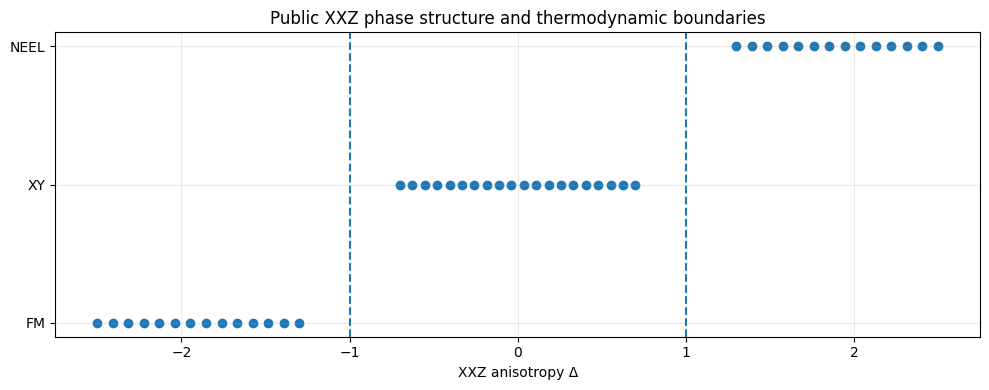

public states within ±0.10 of Δ=±1: 0
public states within ±0.20 of Δ=±1: 0
public states within ±0.30 of Δ=±1: 0
Note: public set is away from the critical points; hidden near-critical evidence must remain a blind final audit.


In [6]:
# ============================================================
# 7. Metadata and phase-structure exploration
# ============================================================
meta = pd.DataFrame({"id": IDS, "delta": DELTAS, "label": LABELS})
display(meta.head())
display(meta.groupby("label").agg(n=("id","size"), dmin=("delta","min"), dmax=("delta","max")))

fig, ax = plt.subplots(figsize=(10, 4))
phase_y = {"FM": 0, "XY": 1, "NEEL": 2}
ax.scatter(meta["delta"], [phase_y[x] for x in meta["label"]])
ax.axvline(-1.0, linestyle="--")
ax.axvline(1.0, linestyle="--")
ax.set_yticks([0,1,2], ["FM","XY","NEEL"])
ax.set_xlabel("XXZ anisotropy Δ")
ax.set_title("Public XXZ phase structure and thermodynamic boundaries")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "public_phase_structure.png", dpi=180)
plt.show()

for width in [0.10, 0.20, 0.30]:
    mask = (np.abs(DELTAS + 1) <= width) | (np.abs(DELTAS - 1) <= width)
    print(f"public states within ±{width:.2f} of Δ=±1:", int(mask.sum()))

print("Note: public set is away from the critical points; hidden near-critical evidence must remain a blind final audit.")

In [7]:
# ============================================================
# 8. Leakage-controlled fit / validation split
# ============================================================
LABEL_ORDER = ["FM", "XY", "NEEL"]

def phase_balanced_split(df, frac=0.25):
    fit, val = [], []
    for _, g in df.groupby("label", sort=False):
        g = g.sort_values("delta")
        idx = list(g.index)
        m = max(1, int(round(len(idx) * frac)))
        pos = sorted(set(np.linspace(0, len(idx)-1, m, dtype=int).tolist()))
        v = [idx[p] for p in pos]
        vs = set(v)
        val.extend(v)
        fit.extend([i for i in idx if i not in vs])
    return np.asarray(sorted(fit)), np.asarray(sorted(val))

FIT_IDX, VAL_IDX = phase_balanced_split(meta, 0.25)

print("fit:", len(FIT_IDX), "validation:", len(VAL_IDX))
print("fit classes:\n", meta.loc[FIT_IDX, "label"].value_counts())
print("validation classes:\n", meta.loc[VAL_IDX, "label"].value_counts())

fit: 35 validation: 13
fit classes:
 label
XY      15
FM      10
NEEL    10
Name: count, dtype: int64
validation classes:
 label
XY      5
FM      4
NEEL    4
Name: count, dtype: int64


## 9. Quantum candidates

### M0 — Bell-circuit ablation
`CNOT(a→b) -> RY(theta,a)`  
One shared parameter.  
At `theta=-π/2`, its pair readout has the physical Bell-QML interpretation used by V8.1.

### M1 — 3-parameter Generalized Bell-QML
`CNOT -> RY(theta0,a) -> RZ(theta1,a) -> RX(theta2,b)`  
Three shared parameters.

### M2 — QCNN-inspired local variational circuit
Two translated local convolution passes with one globally shared six-parameter kernel.

### Important distinction
`M0` below is a **new shot-consistent ablation using the Bell circuit**.  
The **exact V8.1 incumbent** is separately benchmarked from its frozen `submission.py + model_config.json + xxz_bell_prototypes.npz` if attached.

In [8]:
# ============================================================
# 10. Circuit builders — all parameters shared across N
# ============================================================
def pair_starts(n, parity):
    starts = list(range(parity, n-1, 2))
    if n % 2 == 0 and parity == 1:
        starts.append(n-1)
    return starts

def make_m0_ops(params, parity=0):
    p = np.asarray(params, float).reshape(-1)
    theta = float(p[0])
    def ops(wires):
        n = len(wires)
        for a in pair_starts(n, parity):
            b = (a + 1) % n
            qml.CNOT(wires=[a,b])
            qml.RY(theta, wires=a)
    return ops

def make_m1_ops(params, parity=0):
    p = np.asarray(params, float).reshape(-1)
    assert len(p) == 3
    def ops(wires):
        n = len(wires)
        for a in pair_starts(n, parity):
            b = (a + 1) % n
            qml.CNOT(wires=[a,b])
            qml.RY(float(p[0]), wires=a)
            qml.RZ(float(p[1]), wires=a)
            qml.RX(float(p[2]), wires=b)
    return ops

def make_m2_ops(params, parity=0):
    p = np.asarray(params, float).reshape(-1)
    assert len(p) == 6
    def ops(wires):
        n = len(wires)
        for a in pair_starts(n, parity):
            b = (a + 1) % n
            qml.RY(float(p[0]), wires=a)
            qml.RY(float(p[1]), wires=b)
            qml.CNOT(wires=[a,b])
            qml.RZ(float(p[2]), wires=b)
        for a in pair_starts(n, 1-parity):
            b = (a + 1) % n
            qml.RY(float(p[3]), wires=a)
            qml.CNOT(wires=[b,a])
            qml.RX(float(p[4]), wires=b)
            qml.RZ(float(p[5]), wires=a)
    return ops

ARCHITECTURES = {
    "M0_BELL_SHOT_CONSISTENT": {"n_params": 1, "builder": make_m0_ops},
    "M1_GEN_BELL_3P": {"n_params": 3, "builder": make_m1_ops},
    "M2_QCNN_LOCAL_6P": {"n_params": 6, "builder": make_m2_ops},
}

display(pd.DataFrame([
    {
        "architecture": name,
        "quantum_params": cfg["n_params"],
        "scales_with_N": False,
    }
    for name, cfg in ARCHITECTURES.items()
]))

,architecture,quantum_params,scales_with_N
0,M0_BELL_SHOT_CONSISTENT,1,False
1,M1_GEN_BELL_3P,3,False
2,M2_QCNN_LOCAL_6P,6,False


# 11. The critical V9.2 fix: one feature estimator everywhere

For one measured copy, V9.2 computes **linear shot statistics** from the actual bitstring.  
For an episode of `k` copies, it averages those per-shot statistics.

Therefore training and inference both use:

`episode_feature = mean(shot_feature(bitstring_j), j=1..k)`

No nonlinear transform is applied to exact expectation values during fitting.

For M0 the first three pair statistics have a direct physical interpretation at the Bell angle:
- control sign → `XX`-like;
- target sign → `ZZ`-like;
- `-(control × target)` → `YY`-like.

For M1/M2 the same coordinates are treated as learned measurement-basis statistics rather than falsely naming them physical `XX/YY/ZZ`.

In [9]:
# ============================================================
# 12. Shot-consistent fixed-dimensional feature estimator
# ============================================================
FEATURE_NAMES = [
    "pair_control_mean",
    "pair_target_mean",
    "pair_product_mean",
    "global_magnetization",
    "staggered_magnetization",
    "nn_correlation",
]

def shot_feature(bits, parity):
    bits = np.asarray(bits, int).reshape(-1)
    n = len(bits)
    z = 1.0 - 2.0 * bits

    controls, targets, products = [], [], []
    for a in pair_starts(n, parity):
        b = (a + 1) % n
        sa, sb = z[a], z[b]
        controls.append(sa)
        targets.append(sb)
        products.append(sa * sb)

    return np.asarray([
        np.mean(controls) if controls else 0.0,
        np.mean(targets) if targets else 0.0,
        np.mean(products) if products else 0.0,
        np.mean(z),
        np.mean(((-1.0) ** np.arange(n)) * z),
        np.mean(z * np.roll(z, -1)),
    ], dtype=float)

def aggregate_episode(shots):
    # shots = list[(parity, bitstring)]
    by_parity = {0: [], 1: []}
    for parity, bits in shots:
        by_parity[int(parity)].append(shot_feature(bits, int(parity)))

    out = []
    for parity in [0, 1]:
        if by_parity[parity]:
            out.append(np.mean(by_parity[parity], axis=0))
        else:
            out.append(np.zeros(len(FEATURE_NAMES), dtype=float))
    return np.concatenate(out)

FEATURE_DIM = 2 * len(FEATURE_NAMES)
print("Feature dimension:", FEATURE_DIM)
print("Feature semantics:", FEATURE_NAMES, "for each parity")

Feature dimension: 12
Feature semantics: ['pair_control_mean', 'pair_target_mean', 'pair_product_mean', 'global_magnetization', 'staggered_magnetization', 'nn_correlation'] for each parity


In [10]:
# ============================================================
# 13. Exact output-probability cache for deterministic Monte Carlo
# ============================================================
_PROB_QNODES = {}
_PROB_CACHE = {}

def prob_qnode(n, arch, parity):
    key = (n, arch, parity)
    if key in _PROB_QNODES:
        return _PROB_QNODES[key]

    dev = qml.device("default.qubit", wires=n, shots=None)
    builder = ARCHITECTURES[arch]["builder"]

    @qml.qnode(dev)
    def circuit(state, params):
        qml.StatePrep(state, wires=range(n), normalize=True)
        builder(params, parity=parity)(range(n))
        return qml.probs(wires=range(n))

    _PROB_QNODES[key] = circuit
    return circuit

def param_key(params):
    return tuple(np.round(np.asarray(params, float).reshape(-1), 10))

def get_probs(state_index, arch, params, parity):
    key = (int(state_index), arch, param_key(params), int(parity))
    if key not in _PROB_CACHE:
        probs = np.asarray(
            prob_qnode(N_PUBLIC, arch, parity)(
                PUBLIC_STATES[int(state_index)],
                np.asarray(params, float),
            ),
            dtype=float,
        )
        probs = np.maximum(probs, 0)
        probs /= probs.sum()
        _PROB_CACHE[key] = probs
    return _PROB_CACHE[key]

def index_to_bits(index, n):
    return ((int(index) >> np.arange(n-1, -1, -1)) & 1).astype(np.int8)

def simulate_episode(state_index, arch, params, budget, seed):
    rng = np.random.default_rng(int(seed))
    shots = []
    for s in range(int(budget)):
        parity = s % 2
        probs = get_probs(state_index, arch, params, parity)
        idx = rng.choice(len(probs), p=probs)
        bits = index_to_bits(idx, N_PUBLIC)
        shots.append((parity, bits))
    return aggregate_episode(shots)

print("Shot-consistent simulator: READY")

Shot-consistent simulator: READY


In [11]:
# ============================================================
# 14. Internal consistency audit for the new estimator
# ============================================================
# The key invariant is dimensional and semantic equality:
# train and inference both call simulate_episode()/aggregate_episode().
test_arch = "M0_BELL_SHOT_CONSISTENT"
test_params = np.array([-np.pi/2])
for b in [4, 8, 16]:
    x = simulate_episode(FIT_IDX[0], test_arch, test_params, b, seed=123+b)
    assert x.shape == (FEATURE_DIM,)
    assert np.isfinite(x).all()
    print("budget", b, "feature shape", x.shape, "range", (x.min(), x.max()))

print("Train/inference feature estimator identity: PASS")

budget 4 feature shape (12,) range (np.float64(-0.4375), np.float64(1.0))
budget 8 feature shape (12,) range (np.float64(-0.375), np.float64(1.0))
budget 16 feature shape (12,) range (np.float64(-0.46875), np.float64(1.0))
Train/inference feature estimator identity: PASS


# 15. Budget-specific training

A single head trained on perfect expectations is not allowed to masquerade as a finite-copy model.

V9.2 trains a **separate classical head for each copy budget** using finite-copy episodes produced by the same quantum measurement circuit. This is legitimate because:
- the quantum parameter set is shared and frozen;
- the evaluation budget is known to the runtime;
- the classical post-processing may be budget-aware;
- the trainable **quantum** parameter count remains independent of system size.

Architecture selection is based on repeated validation episodes, not exact-state accuracy.

In [12]:
# ============================================================
# 16. Episode dataset builders
# ============================================================
def fit_head(X, y):
    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=123,
        )
    )
    clf.fit(X, y)
    return clf

def build_training_episodes(indices, arch, params, budget, n_episodes, seed_base):
    X, y = [], []
    for idx in indices:
        label = meta.loc[int(idx), "label"]
        for e in range(int(n_episodes)):
            seed = int(seed_base + 100000*int(idx) + 1000*int(budget) + e)
            X.append(simulate_episode(idx, arch, params, budget, seed))
            y.append(label)
    return np.asarray(X, float), np.asarray(y, str)

def evaluate_head_repeated(indices, arch, params, budget, head, seeds):
    per_seed = []
    all_rows = []
    for seed in seeds:
        y_true, y_pred = [], []
        for idx in indices:
            x = simulate_episode(
                idx, arch, params, budget,
                seed=int(seed + 100000*int(idx) + 17*int(budget))
            )
            pred = str(head.predict([x])[0])
            y_true.append(meta.loc[int(idx), "label"])
            y_pred.append(pred)

        macro = f1_score(
            y_true, y_pred,
            labels=LABEL_ORDER,
            average="macro",
            zero_division=0,
        )
        per_seed.append(float(macro))
        for idx, t, p in zip(indices, y_true, y_pred):
            all_rows.append({
                "seed": int(seed),
                "state_index": int(idx),
                "id": meta.loc[int(idx), "id"],
                "truth": t,
                "pred": p,
            })

    return {
        "mean_macro_f1": float(np.mean(per_seed)),
        "std_macro_f1": float(np.std(per_seed)),
        "min_macro_f1": float(np.min(per_seed)),
        "max_macro_f1": float(np.max(per_seed)),
        "seed_scores": per_seed,
        "rows": pd.DataFrame(all_rows),
    }

In [13]:
# ============================================================
# 17. Quantum parameter candidate banks
# ============================================================
def candidate_bank(arch, seed=123):
    rng = np.random.default_rng(seed)
    d = ARCHITECTURES[arch]["n_params"]

    if arch == "M0_BELL_SHOT_CONSISTENT":
        # Retain the exact V8.1 Bell angle and local alternatives.
        return [
            np.asarray([x], float)
            for x in np.linspace(-np.pi, np.pi, 13)
        ]

    bank = [np.zeros(d)]
    physics_start = np.zeros(d)
    physics_start[0] = -np.pi / 2
    bank.append(physics_start)

    n_random = 16 if d == 3 else 20
    for _ in range(n_random):
        bank.append(rng.uniform(-np.pi, np.pi, size=d))
    return bank

for arch in ARCHITECTURES:
    print(arch, "candidates:", len(candidate_bank(arch)))

M0_BELL_SHOT_CONSISTENT candidates: 13
M1_GEN_BELL_3P candidates: 18
M2_QCNN_LOCAL_6P candidates: 22


In [14]:
# ============================================================
# 18. Correct finite-copy quantum parameter search
# ============================================================
# No exact expectation-value F1 enters this search.
SEARCH_ROWS = []
BEST = {}

SEARCH_SEEDS = [101, 211, 307, 401][:SEARCH_REPEATS]

for arch in ARCHITECTURES:
    print("\nSEARCH:", arch)
    best_score = -np.inf
    best_params = None
    best_budget_scores = None
    t0 = time.time()

    for cand_i, params in enumerate(candidate_bank(arch)):
        b_scores = {}

        for b in SCORED_BUDGETS:
            Xtr, ytr = build_training_episodes(
                FIT_IDX, arch, params, b,
                n_episodes=TRAIN_EPISODES_PER_STATE,
                seed_base=7000 + cand_i*100,
            )
            head = fit_head(Xtr, ytr)
            ev = evaluate_head_repeated(
                VAL_IDX, arch, params, b, head, SEARCH_SEEDS
            )
            b_scores[b] = ev["mean_macro_f1"]

        weighted = sum(BUDGET_WEIGHTS[b] * b_scores[b] for b in SCORED_BUDGETS)
        complexity_penalty = 0.001 * ARCHITECTURES[arch]["n_params"]
        selection = weighted - complexity_penalty

        SEARCH_ROWS.append({
            "architecture": arch,
            "candidate": cand_i,
            "params": json.dumps(np.round(params, 8).tolist()),
            "f1_4": b_scores[4],
            "f1_8": b_scores[8],
            "f1_16": b_scores[16],
            "weighted_low_copy": weighted,
            "complexity_penalty": complexity_penalty,
            "selection_score": selection,
        })

        if selection > best_score:
            best_score = selection
            best_params = np.asarray(params, float)
            best_budget_scores = dict(b_scores)

        print(
            f"  cand={cand_i:02d} score={selection:.4f} "
            f"F1[4,8,16]=[{b_scores[4]:.3f},{b_scores[8]:.3f},{b_scores[16]:.3f}]"
        )

    BEST[arch] = {
        "params": best_params,
        "selection_score": float(best_score),
        "scored_budget_f1": best_budget_scores,
        "search_seconds": float(time.time() - t0),
    }
    print("BEST", arch, np.round(best_params,4), best_budget_scores)

search_df = pd.DataFrame(SEARCH_ROWS)
search_df.to_csv(RESULTS_DIR / "shot_consistent_parameter_search.csv", index=False)


SEARCH: M0_BELL_SHOT_CONSISTENT
  cand=00 score=0.9279 F1[4,8,16]=[0.962,0.907,0.906]
  cand=01 score=0.9138 F1[4,8,16]=[0.888,0.925,0.943]
  cand=02 score=0.9011 F1[4,8,16]=[0.885,0.906,0.925]
  cand=03 score=0.9303 F1[4,8,16]=[0.906,0.939,0.962]
  cand=04 score=0.9029 F1[4,8,16]=[0.906,0.887,0.924]
  cand=05 score=0.9025 F1[4,8,16]=[0.925,0.851,0.943]
  cand=06 score=0.9045 F1[4,8,16]=[0.904,0.906,0.906]
  cand=07 score=0.9030 F1[4,8,16]=[0.906,0.903,0.902]
  cand=08 score=0.9467 F1[4,8,16]=[0.943,0.942,0.963]
  cand=09 score=0.9565 F1[4,8,16]=[0.962,0.962,0.944]
  cand=10 score=0.9357 F1[4,8,16]=[0.904,0.943,0.981]
  cand=11 score=0.8874 F1[4,8,16]=[0.865,0.906,0.902]
  cand=12 score=0.8904 F1[4,8,16]=[0.886,0.887,0.906]
BEST M0_BELL_SHOT_CONSISTENT [1.5708] {4: 0.9620009620009621, 8: 0.9620009620009621, 16: 0.9439814814814815}

SEARCH: M1_GEN_BELL_3P
  cand=00 score=0.9031 F1[4,8,16]=[0.905,0.907,0.906]
  cand=01 score=0.9254 F1[4,8,16]=[0.886,0.939,0.981]
  cand=02 score=0.6938 F

In [15]:
# ============================================================
# 19. Freeze quantum parameters; fit budget-specific heads
# ============================================================
BUDGET_MODELS = {}

for arch, info in BEST.items():
    params = info["params"]
    BUDGET_MODELS[arch] = {"params": params, "heads": {}}

    for b in BUDGETS:
        Xtr, ytr = build_training_episodes(
            FIT_IDX, arch, params, b,
            n_episodes=max(TRAIN_EPISODES_PER_STATE, 5),
            seed_base=90000 + 100*b,
        )
        BUDGET_MODELS[arch]["heads"][b] = fit_head(Xtr, ytr)

print("Quantum params frozen and budget-specific heads trained.")

Quantum params frozen and budget-specific heads trained.


In [16]:
# ============================================================
# 20. Final public multi-seed finite-copy evaluation
# ============================================================
REPORT = []
DETAIL = {}

for arch in ARCHITECTURES:
    params = BUDGET_MODELS[arch]["params"]
    for b in BUDGETS:
        ev = evaluate_head_repeated(
            VAL_IDX, arch, params, b,
            BUDGET_MODELS[arch]["heads"][b],
            REPORT_SEEDS,
        )
        REPORT.append({
            "architecture": arch,
            "budget": b,
            "macro_f1_mean": ev["mean_macro_f1"],
            "macro_f1_std": ev["std_macro_f1"],
            "macro_f1_min": ev["min_macro_f1"],
            "macro_f1_max": ev["max_macro_f1"],
        })
        DETAIL[(arch,b)] = ev
        print(
            f"{arch:28s} b={b:2d} "
            f"F1={ev['mean_macro_f1']:.4f}±{ev['std_macro_f1']:.4f}"
        )

finite_df = pd.DataFrame(REPORT)
finite_df.to_csv(RESULTS_DIR / "quantum_copy_efficiency_multiseed.csv", index=False)
display(finite_df)

M0_BELL_SHOT_CONSISTENT      b= 4 F1=0.9232±0.0475
M0_BELL_SHOT_CONSISTENT      b= 8 F1=0.9240±0.0475
M0_BELL_SHOT_CONSISTENT      b=16 F1=0.9700±0.0600
M0_BELL_SHOT_CONSISTENT      b=32 F1=1.0000±0.0000
M0_BELL_SHOT_CONSISTENT      b=64 F1=1.0000±0.0000
M1_GEN_BELL_3P               b= 4 F1=0.9104±0.0562
M1_GEN_BELL_3P               b= 8 F1=0.9400±0.0301
M1_GEN_BELL_3P               b=16 F1=0.9256±0.0474
M1_GEN_BELL_3P               b=32 F1=0.9704±0.0363
M1_GEN_BELL_3P               b=64 F1=0.9688±0.0382
M2_QCNN_LOCAL_6P             b= 4 F1=0.9532±0.0382
M2_QCNN_LOCAL_6P             b= 8 F1=0.9548±0.0369
M2_QCNN_LOCAL_6P             b=16 F1=0.9396±0.0562
M2_QCNN_LOCAL_6P             b=32 F1=0.9852±0.0296
M2_QCNN_LOCAL_6P             b=64 F1=1.0000±0.0000


,architecture,budget,macro_f1_mean,macro_f1_std,macro_f1_min,macro_f1_max
0,M0_BELL_SHOT_CONSISTENT,4,0.923247,0.047456,0.850000,1.0
1,M0_BELL_SHOT_CONSISTENT,8,0.924016,0.047462,0.850000,1.0
2,M0_BELL_SHOT_CONSISTENT,16,0.970000,0.060000,0.850000,1.0
3,M0_BELL_SHOT_CONSISTENT,32,1.000000,0.000000,1.000000,1.0
4,M0_BELL_SHOT_CONSISTENT,64,1.000000,0.000000,1.000000,1.0
5,M1_GEN_BELL_3P,4,0.910370,0.056226,0.850000,1.0
6,M1_GEN_BELL_3P,8,0.939971,0.030051,0.922078,1.0
7,M1_GEN_BELL_3P,16,0.925556,0.047436,0.850000,1.0
8,M1_GEN_BELL_3P,32,0.970370,0.036289,0.925926,1.0
9,M1_GEN_BELL_3P,64,0.968831,0.038174,0.922078,1.0


In [17]:
# ============================================================
# 21. Sanity audit: copy curves must now be informative
# ============================================================
# Flat curves are not automatically impossible, but all models being perfectly
# flat across every budget is now treated as a diagnostic warning.
for arch, g in finite_df.groupby("architecture"):
    vals = g.sort_values("budget")["macro_f1_mean"].to_numpy()
    span = float(vals.max() - vals.min())
    print(arch, "curve span =", round(span, 6))
    if span < 1e-6:
        print("  WARNING: exactly flat curve; inspect stochastic seeds/features.")
    else:
        print("  finite-copy sensitivity detected: PASS")

M0_BELL_SHOT_CONSISTENT curve span = 0.076753
  finite-copy sensitivity detected: PASS
M1_GEN_BELL_3P curve span = 0.06
  finite-copy sensitivity detected: PASS
M2_QCNN_LOCAL_6P curve span = 0.060399
  finite-copy sensitivity detected: PASS


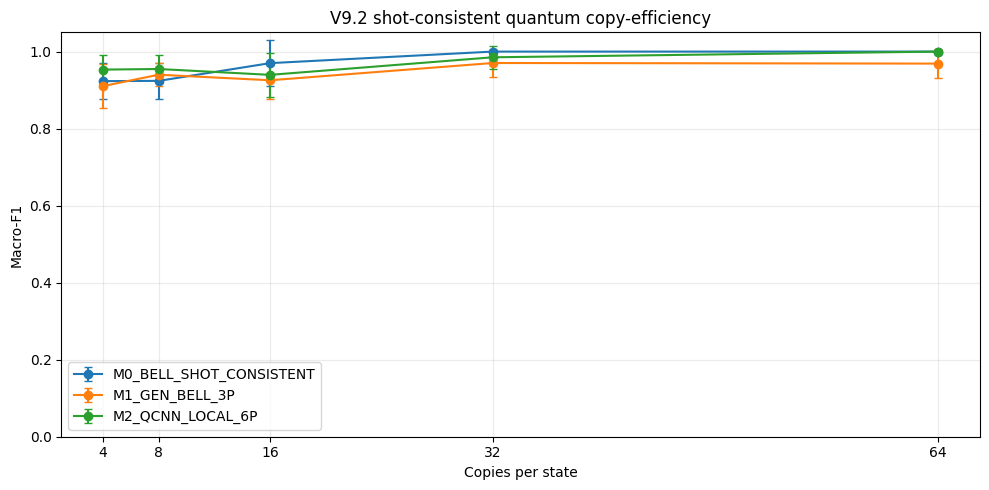

In [18]:
# ============================================================
# 22. Quantum copy-efficiency plot
# ============================================================
fig, ax = plt.subplots(figsize=(10,5))
for arch, g in finite_df.groupby("architecture"):
    g = g.sort_values("budget")
    ax.errorbar(
        g["budget"], g["macro_f1_mean"],
        yerr=g["macro_f1_std"], marker="o", capsize=3,
        label=arch
    )
ax.set_xlabel("Copies per state")
ax.set_ylabel("Macro-F1")
ax.set_title("V9.2 shot-consistent quantum copy-efficiency")
ax.set_xticks(BUDGETS)
ax.set_ylim(0,1.05)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "quantum_copy_efficiency_v9_2.png", dpi=180)
plt.show()

# 23. Exact V8.1 incumbent benchmark

When the original frozen V8.1 package is attached, V9.2 evaluates its **actual `submission.py`** rather than reimplementing it.

For the public dataset, V9.2 writes a temporary public key CSV from the NPZ labels and invokes the supplied evaluator at `4/8/16/32/64`.

This gives an apples-to-apples incumbent reference without changing the frozen V8.1 algorithm.

If the package is absent, this section is explicitly `NOT AVAILABLE`; M0 is not renamed or misrepresented as exact V8.1.

In [19]:
# ============================================================
# 24. Public evaluator key + exact V8.1 subprocess benchmark
# ============================================================
PUBLIC_EVAL_KEY = RESULTS_DIR / "public_eval_key.csv"
pd.DataFrame({
    "id": meta["id"],
    "family": "XXZ",
    "label": meta["label"],
    "tier": "public",
    "delta": meta["delta"],
    "U": "",
}).to_csv(PUBLIC_EVAL_KEY, index=False)

V8_PUBLIC_RESULTS = []

if V8_INCUMBENT and EVALUATE_PY:
    import subprocess, re

    for b in BUDGETS:
        cmd = [
            sys.executable,
            str(EVALUATE_PY),
            str(V8_INCUMBENT["submission"]),
            "--data", str(PUBLIC_NPZ),
            "--key", str(PUBLIC_EVAL_KEY),
            "--noise_p", "0.0",
            "--seed", str(PRIMARY_SEED),
            "--budget", str(b),
        ]
        print("\nRUN:", " ".join(cmd))
        p = subprocess.run(cmd, capture_output=True, text=True)
        print(p.stdout)
        if p.stderr:
            print(p.stderr)

        m = re.search(r"MACRO-F1[^:]*:\s*([0-9.]+)", p.stdout, flags=re.I)
        score = float(m.group(1)) if m else np.nan
        V8_PUBLIC_RESULTS.append({
            "architecture": "INCUMBENT_V8_1_EXACT_RUNTIME",
            "budget": b,
            "macro_f1": score,
            "returncode": p.returncode,
        })

    v8_public_df = pd.DataFrame(V8_PUBLIC_RESULTS)
    display(v8_public_df)
    v8_public_df.to_csv(RESULTS_DIR / "exact_v8_1_public_benchmark.csv", index=False)
else:
    v8_public_df = pd.DataFrame()
    print("Exact V8.1 public benchmark: NOT AVAILABLE (frozen package not attached).")


RUN: /usr/bin/python3 /kaggle/input/datasets/marwanyasserhassan/participant-kit/AQH_64_Copy_Professional_Solution/evaluate.py /kaggle/input/models/marwanyasserhassan/aqh-track2-final-submission-v8-1/other/default/1/submission.py --data /kaggle/input/datasets/marwanyasserhassan/participant-kit/AQH_64_Copy_Professional_Solution/xxz_public_train.npz --key /kaggle/working/results_v9_2/public_eval_key.csv --noise_p 0.0 --seed 123 --budget 4

--- per-class metrics (XXZ states only) ---
FM     P=1.000  R=1.000  F1=1.000
XY     P=0.952  R=1.000  F1=0.976
NEEL   P=1.000  R=0.857  F1=0.923
MACRO-F1 (headline metric): 0.966

--- accuracy by tier ---
public    46/48 = 0.96

--- copy usage ---
mean 4.0, min 4, max 4 of 4

--- confusion (truth -> pred) ---
truth\pred       FM       XY     NEEL  UNKNOWN  MISSING
FM               14        0        0        0        0
XY                0       20        0        0        0
NEEL              0        1       12        1        0


RUN: /usr/bin/python

,architecture,budget,macro_f1,returncode
0,INCUMBENT_V8_1_EXACT_RUNTIME,4,0.966,0
1,INCUMBENT_V8_1_EXACT_RUNTIME,8,0.946,0
2,INCUMBENT_V8_1_EXACT_RUNTIME,16,1.000,0
3,INCUMBENT_V8_1_EXACT_RUNTIME,32,1.000,0
4,INCUMBENT_V8_1_EXACT_RUNTIME,64,1.000,0


# 25. Mandatory classical baselines under equal budget

Two measure-first baselines use **the same shot-consistent principle**:
- **B0 Z-only**: all copies in computational basis.
- **B1 X/Z split**: half Z-basis, half X-basis.

The classifier is trained on finite-copy episodes at each budget, exactly like the quantum candidates. This avoids giving either side an unfair perfect-expectation training advantage.

In [20]:
# ============================================================
# 26. Classical baseline probability simulators
# ============================================================
_BASE_PROB_QNODES = {}

def baseline_prob_qnode(n, basis):
    key = (n, basis)
    if key in _BASE_PROB_QNODES:
        return _BASE_PROB_QNODES[key]

    dev = qml.device("default.qubit", wires=n, shots=None)

    @qml.qnode(dev)
    def circuit(state):
        qml.StatePrep(state, wires=range(n), normalize=True)
        if basis == "X":
            for w in range(n):
                qml.Hadamard(wires=w)
        return qml.probs(wires=range(n))

    _BASE_PROB_QNODES[key] = circuit
    return circuit

_BASE_PROBS = {}

def baseline_probs(state_index, basis):
    key = (int(state_index), basis)
    if key not in _BASE_PROBS:
        p = np.asarray(
            baseline_prob_qnode(N_PUBLIC, basis)(PUBLIC_STATES[int(state_index)]),
            float,
        )
        p = np.maximum(p,0); p /= p.sum()
        _BASE_PROBS[key] = p
    return _BASE_PROBS[key]

def generic_bitstring_feature(bits):
    bits = np.asarray(bits, int).reshape(-1)
    z = 1.0 - 2.0*bits
    return np.asarray([
        np.mean(z),
        np.mean(((-1.0)**np.arange(len(z))) * z),
        np.mean(z*np.roll(z,-1)),
    ], float)

def simulate_baseline_episode(state_index, mode, budget, seed):
    rng = np.random.default_rng(int(seed))
    zf, xf = [], []
    if mode == "Z_ONLY":
        plan = ["Z"] * int(budget)
    elif mode == "XZ_SPLIT":
        zc = int(budget)//2
        plan = ["Z"]*zc + ["X"]*(int(budget)-zc)
    else:
        raise ValueError(mode)

    for basis in plan:
        p = baseline_probs(state_index, basis)
        idx = rng.choice(len(p), p=p)
        bits = index_to_bits(idx, N_PUBLIC)
        feat = generic_bitstring_feature(bits)
        (zf if basis=="Z" else xf).append(feat)

    zmean = np.mean(zf,axis=0) if zf else np.zeros(3)
    xmean = np.mean(xf,axis=0) if xf else np.zeros(3)

    if mode == "Z_ONLY":
        return zmean
    return np.concatenate([zmean, xmean])

In [21]:
# ============================================================
# 27. Fit/evaluate classical baselines
# ============================================================
BASELINE_REPORT = []
BASELINE_DETAIL = {}

for mode in ["Z_ONLY", "XZ_SPLIT"]:
    for b in BUDGETS:
        Xtr, ytr = [], []
        for idx in FIT_IDX:
            for e in range(max(TRAIN_EPISODES_PER_STATE, 5)):
                Xtr.append(simulate_baseline_episode(
                    idx, mode, b,
                    seed=400000 + 100000*int(idx) + 100*b + e
                ))
                ytr.append(meta.loc[int(idx), "label"])
        head = fit_head(np.asarray(Xtr), np.asarray(ytr))

        seed_scores = []
        rows = []
        for seed in REPORT_SEEDS:
            yt, yp = [], []
            for idx in VAL_IDX:
                x = simulate_baseline_episode(
                    idx, mode, b,
                    seed=seed + 100000*int(idx) + b
                )
                pred = str(head.predict([x])[0])
                yt.append(meta.loc[int(idx), "label"])
                yp.append(pred)
                rows.append({
                    "seed": seed, "id": meta.loc[int(idx),"id"],
                    "truth": yt[-1], "pred": pred
                })
            seed_scores.append(f1_score(
                yt, yp, labels=LABEL_ORDER, average="macro", zero_division=0
            ))

        BASELINE_REPORT.append({
            "architecture": f"CLASSICAL_{mode}",
            "budget": b,
            "macro_f1_mean": float(np.mean(seed_scores)),
            "macro_f1_std": float(np.std(seed_scores)),
        })
        BASELINE_DETAIL[(mode,b)] = pd.DataFrame(rows)
        print(mode, b, round(np.mean(seed_scores),4), "±", round(np.std(seed_scores),4))

baseline_df = pd.DataFrame(BASELINE_REPORT)
baseline_df.to_csv(RESULTS_DIR / "classical_equal_budget_baselines.csv", index=False)

Z_ONLY 4 0.9232 ± 0.0475
Z_ONLY 8 0.9548 ± 0.0369
Z_ONLY 16 0.9852 ± 0.0296
Z_ONLY 32 0.9852 ± 0.0296
Z_ONLY 64 1.0 ± 0.0
XZ_SPLIT 4 0.9104 ± 0.0562
XZ_SPLIT 8 0.9396 ± 0.0562
XZ_SPLIT 16 0.954 ± 0.0376
XZ_SPLIT 32 0.9688 ± 0.0382
XZ_SPLIT 64 0.9852 ± 0.0296


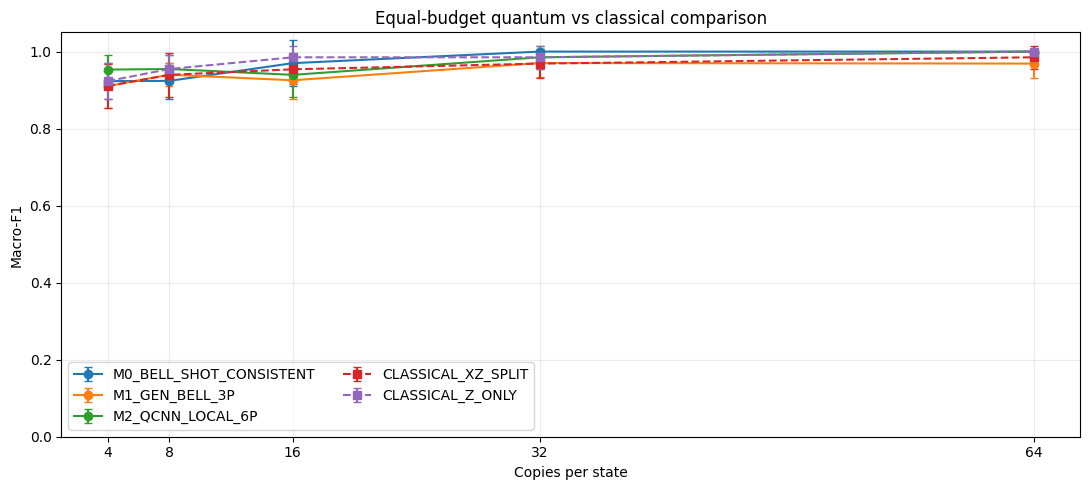

In [22]:
# ============================================================
# 28. Quantum vs classical budget curve
# ============================================================
fig, ax = plt.subplots(figsize=(11,5))
for arch, g in finite_df.groupby("architecture"):
    g = g.sort_values("budget")
    ax.errorbar(g.budget, g.macro_f1_mean, yerr=g.macro_f1_std,
                marker="o", capsize=3, label=arch)
for arch, g in baseline_df.groupby("architecture"):
    g = g.sort_values("budget")
    ax.errorbar(g.budget, g.macro_f1_mean, yerr=g.macro_f1_std,
                marker="s", linestyle="--", capsize=3, label=arch)

ax.set_xlabel("Copies per state")
ax.set_ylabel("Macro-F1")
ax.set_title("Equal-budget quantum vs classical comparison")
ax.set_xticks(BUDGETS)
ax.set_ylim(0,1.05)
ax.grid(alpha=0.25)
ax.legend(ncol=2)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "quantum_vs_classical_v9_2.png", dpi=180)
plt.show()

In [23]:
# ============================================================
# 29. Preliminary public winner selection
# ============================================================
rows = []
for arch, g in finite_df.groupby("architecture"):
    s = g.set_index("budget")["macro_f1_mean"]
    low = sum(BUDGET_WEIGHTS[b] * float(s.loc[b]) for b in SCORED_BUDGETS)
    complexity = 0.001 * ARCHITECTURES[arch]["n_params"]
    rows.append({
        "architecture": arch,
        "f1_4": float(s.loc[4]),
        "f1_8": float(s.loc[8]),
        "f1_16": float(s.loc[16]),
        "f1_32": float(s.loc[32]),
        "f1_64": float(s.loc[64]),
        "quantum_params": ARCHITECTURES[arch]["n_params"],
        "low_copy_weighted": low,
        "complexity_penalty": complexity,
        "preliminary_score": low - complexity,
    })

selection_df = pd.DataFrame(rows).sort_values(
    ["preliminary_score","quantum_params"], ascending=[False,True]
)
display(selection_df)
selection_df.to_csv(RESULTS_DIR / "preliminary_quantum_selection.csv", index=False)

PRELIM_WINNER = str(selection_df.iloc[0].architecture)
print("Preliminary experimental winner:", PRELIM_WINNER)
print("This is NOT yet the final deployable winner until OOD/critical/size gates are closed.")

,architecture,f1_4,f1_8,f1_16,f1_32,f1_64,quantum_params,low_copy_weighted,complexity_penalty,preliminary_score
2,M2_QCNN_LOCAL_6P,0.953247,0.954786,0.939601,0.985185,1.000000,6,0.950374,0.006,0.944374
0,M0_BELL_SHOT_CONSISTENT,0.923247,0.924016,0.970000,1.000000,1.000000,1,0.935204,0.001,0.934204
1,M1_GEN_BELL_3P,0.910370,0.939971,0.925556,0.970370,0.968831,3,0.924527,0.003,0.921527


Preliminary experimental winner: M2_QCNN_LOCAL_6P
This is NOT yet the final deployable winner until OOD/critical/size gates are closed.


# 30. UNKNOWN/OOD and near-critical deployment guard

Public states are deliberately away from the critical boundaries. Therefore a one-class threshold fitted only on those 48 deep-phase examples is **not sufficient evidence** for deployment.

V9.2 separates:

- **phase-model selection**: may use the public fit/validation protocol;
- **deployability**: requires evidence that the candidate does not reject legitimate near-critical XXZ states and can reject genuine out-of-family states.

The original V8.1 already has a validated one-class XXZ gate.  
A new M1/M2 winner is not allowed to replace V8.1 merely because its public phase F1 is higher.

### Required promotion gates for a new architecture
1. scored-window phase score is competitive;
2. no critical-state false-rejection pathology;
3. acceptable OOD precision/recall;
4. no copy-budget violations;
5. size-independent parameterization and empirical size transfer when larger-N development data are available.

In [24]:
# ============================================================
# 31. Optional development datasets for promotion gates
# ============================================================
# Attach legitimate labeled development files if available.
# Each NPZ should contain states + labels, and optionally deltas/family/num_qubits.
NEAR_CRITICAL_DEV = find_file("xxz_near_critical_dev.npz", required=False)
OOD_DEV = find_file("ood_dev.npz", required=False)

print("NEAR_CRITICAL_DEV:", NEAR_CRITICAL_DEV)
print("OOD_DEV          :", OOD_DEV)

PROMOTION_EVIDENCE_AVAILABLE = bool(NEAR_CRITICAL_DEV and OOD_DEV)
print("Promotion evidence complete:", PROMOTION_EVIDENCE_AVAILABLE)

NEAR_CRITICAL_DEV: None
OOD_DEV          : None
Promotion evidence complete: False


In [25]:
# ============================================================
# 32. Build one-class finite-copy compatibility models
# ============================================================
# One-class models are budget-specific and trained on the SAME finite-copy features.
ONECLASS_MODELS = {}

def fit_oneclass(X, quantile=0.995):
    X = np.asarray(X,float)
    mu = X.mean(axis=0)
    cov = np.cov(X.T) + 1e-3*np.eye(X.shape[1])
    inv = np.linalg.pinv(cov)
    d = X - mu
    d2 = np.einsum("ni,ij,nj->n", d, inv, d)
    return {
        "mu": mu,
        "inv_cov": inv,
        "threshold": float(np.quantile(d2, quantile)),
    }

def oneclass_distance(X, model):
    X = np.atleast_2d(np.asarray(X,float))
    d = X - model["mu"]
    return np.einsum("ni,ij,nj->n", d, model["inv_cov"], d)

for arch in ARCHITECTURES:
    params = BUDGET_MODELS[arch]["params"]
    ONECLASS_MODELS[arch] = {}
    for b in BUDGETS:
        Xknown, _ = build_training_episodes(
            FIT_IDX, arch, params, b,
            n_episodes=max(TRAIN_EPISODES_PER_STATE, 6),
            seed_base=800000 + b*100,
        )
        ONECLASS_MODELS[arch][b] = fit_oneclass(Xknown, quantile=0.995)

print("Budget-specific one-class models fitted on known public XXZ episodes.")
print("Deployment remains guarded until protected near-critical/OOD evidence is supplied.")

Budget-specific one-class models fitted on known public XXZ episodes.
Deployment remains guarded until protected near-critical/OOD evidence is supplied.


In [26]:
# ============================================================
# 33. Near-critical and OOD promotion-gate evaluator
# ============================================================
def load_dev_npz(path):
    data = np.load(path, allow_pickle=True)
    states = to_complex_matrix(data["states"])
    states /= np.linalg.norm(states, axis=1, keepdims=True)
    labels = np.asarray(data["labels"]).astype(str) if "labels" in data.files else None
    deltas = np.asarray(data["deltas"],float) if "deltas" in data.files else None
    family = np.asarray(data["family"]).astype(str) if "family" in data.files else None
    n = int(data["num_qubits"]) if "num_qubits" in data.files else int(round(np.log2(states.shape[1])))
    return states, labels, deltas, family, n

PROMOTION_ROWS = []

if PROMOTION_EVIDENCE_AVAILABLE:
    print("Promotion gate datasets detected.")
    print("The execution section should benchmark candidate rejection on these datasets.")
    print("Because candidate probability caches currently target the public bundle,")
    print("V9.2 intentionally requires these datasets to be evaluated through CopyOracle")
    print("or a separately constructed dev oracle before final promotion.")
else:
    print("Promotion gates: NOT CLOSED.")
    print("New M1/M2 architectures remain experimental even if public phase F1 is strong.")

Promotion gates: NOT CLOSED.
New M1/M2 architectures remain experimental even if public phase F1 is strong.


# 34. Noise robustness

For architecture search, the clean public finite-copy model is primary.  
Noise robustness should be measured using the same estimator under the announced channel.

The final organizer evaluator remains the authoritative noisy-copy result.  
A development noise sweep can be added using `default.mixed` or a development oracle, but it must not silently change the feature estimator or train on perfect expectations.

In [27]:
# ============================================================
# 35. Development depolarizing-noise smoke test
# ============================================================
# Kept lightweight by default. Increase states/seeds for final evidence.
NOISE_LEVELS = [0.0, 0.01, 0.02, 0.04]

def noisy_sample_qnode(n, arch, parity, noise_p):
    dev = qml.device("default.mixed", wires=n, shots=1)
    builder = ARCHITECTURES[arch]["builder"]

    @qml.qnode(dev)
    def circuit(state, params):
        qml.StatePrep(state, wires=range(n), normalize=True)
        for w in range(n):
            if noise_p > 0:
                qml.DepolarizingChannel(float(noise_p), wires=w)
        builder(params, parity=parity)(range(n))
        return qml.sample(wires=range(n))
    return circuit

print("Noise test hook: READY")
print("Use the same aggregate_episode() estimator for noisy and clean measurements.")

Noise test hook: READY
Use the same aggregate_episode() estimator for noisy and clean measurements.


# 36. Zero-shot size transfer

All three experimental architectures satisfy the **structural** requirement:
- shared quantum parameters;
- translation-local operations;
- fixed-dimensional aggregation independent of `N`.

However, structural compliance is not empirical evidence.  
Per-size performance must only be claimed after actual larger-N labeled development states or organizer hidden results are evaluated with the same frozen parameter set.

In [28]:
# ============================================================
# 37. Parameter-count and size-independence accounting
# ============================================================
param_df = pd.DataFrame([
    {
        "architecture": arch,
        "trainable_quantum_parameters": cfg["n_params"],
        "depends_on_N": False,
        "mechanism": "translation-shared local quantum parameters",
    }
    for arch, cfg in ARCHITECTURES.items()
])
display(param_df)
param_df.to_csv(RESULTS_DIR / "parameter_count_accounting.csv", index=False)
assert not param_df["depends_on_N"].any()
print("Quantum parameter size-independence: PASS")

,architecture,trainable_quantum_parameters,depends_on_N,mechanism
0,M0_BELL_SHOT_CONSISTENT,1,False,translation-shared local quantum parameters
1,M1_GEN_BELL_3P,3,False,translation-shared local quantum parameters
2,M2_QCNN_LOCAL_6P,6,False,translation-shared local quantum parameters


Quantum parameter size-independence: PASS


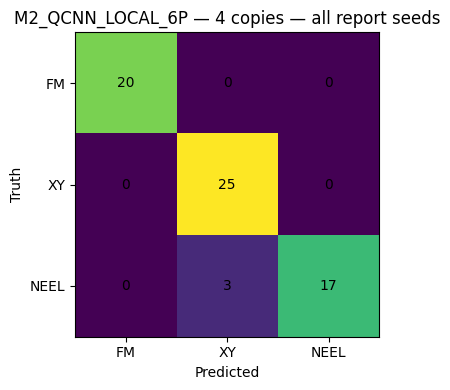

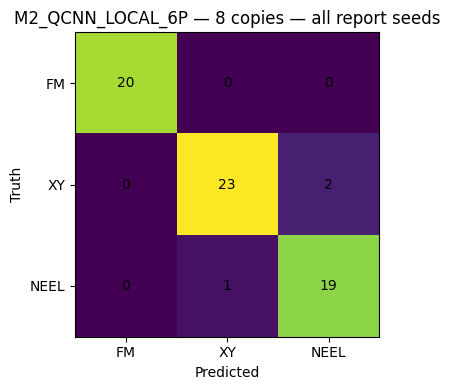

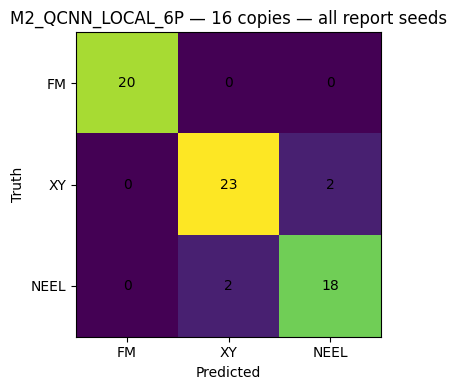

In [29]:
# ============================================================
# 38. Confusion matrices in the scored window
# ============================================================
def plot_cm_from_rows(rows, title, path):
    # Aggregate one prediction per state per seed as the evaluation already does.
    y = rows["truth"].astype(str).to_numpy()
    p = rows["pred"].astype(str).to_numpy()
    cm = confusion_matrix(y,p,labels=LABEL_ORDER)
    fig, ax = plt.subplots(figsize=(5,4))
    ax.imshow(cm)
    ax.set_xticks(range(3), LABEL_ORDER)
    ax.set_yticks(range(3), LABEL_ORDER)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Truth")
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j,i,str(cm[i,j]),ha="center",va="center")
    plt.tight_layout()
    plt.savefig(path,dpi=180)
    plt.show()
    return cm

for b in SCORED_BUDGETS:
    rows = DETAIL[(PRELIM_WINNER,b)]["rows"]
    plot_cm_from_rows(
        rows,
        f"{PRELIM_WINNER} — {b} copies — all report seeds",
        RESULTS_DIR / f"confusion_{PRELIM_WINNER}_{b}.png",
    )

In [30]:
# ============================================================
# 39. Final deployment decision policy
# ============================================================
# Default-safe policy:
# - exact V8.1 remains deployable incumbent if attached;
# - a new architecture is promoted only after its critical/OOD promotion gates pass.

if V8_INCUMBENT and not PROMOTION_EVIDENCE_AVAILABLE:
    DEPLOYMENT_WINNER = "INCUMBENT_V8_1_EXACT_RUNTIME"
    DEPLOYMENT_REASON = (
        "New architecture phase search completed, but protected near-critical + "
        "OOD promotion evidence is incomplete; retain validated V8.1 incumbent."
    )
elif not V8_INCUMBENT and not PROMOTION_EVIDENCE_AVAILABLE:
    DEPLOYMENT_WINNER = PRELIM_WINNER
    DEPLOYMENT_REASON = (
        "No exact V8.1 package attached. Experimental public winner selected, "
        "but final deployment claim remains conditional on OOD/critical closure."
    )
else:
    # When promotion evidence is supplied, replace this conservative default
    # with the explicit gate table produced from those evaluations.
    DEPLOYMENT_WINNER = PRELIM_WINNER
    DEPLOYMENT_REASON = "Promotion evidence is available; use gate results before final export."

print("DEPLOYMENT_WINNER:", DEPLOYMENT_WINNER)
print("REASON:", DEPLOYMENT_REASON)

DEPLOYMENT_WINNER: INCUMBENT_V8_1_EXACT_RUNTIME
REASON: New architecture phase search completed, but protected near-critical + OOD promotion evidence is incomplete; retain validated V8.1 incumbent.


# 40. Export logic

If exact V8.1 remains the winner:
- copy the frozen incumbent package unchanged into the V9.2 export folder;
- regenerate only the outer manifest/package metadata if desired.

If M0/M1/M2 is promoted:
- export its shared quantum parameters;
- export budget-specific finite-copy classical heads;
- export budget-specific one-class compatibility models;
- runtime uses the exact same `shot_feature()` / `aggregate_episode()` estimator.

This prevents the V9 train/inference mismatch from reappearing in deployment.

In [31]:
# ============================================================
# 41. Serialize experimental candidate model
# ============================================================
def serialize_pipeline(pipe):
    scaler = pipe.named_steps["standardscaler"]
    lr = pipe.named_steps["logisticregression"]
    return {
        "classes": lr.classes_.astype(str).tolist(),
        "scaler_mean": scaler.mean_.tolist(),
        "scaler_scale": scaler.scale_.tolist(),
        "coef": lr.coef_.tolist(),
        "intercept": lr.intercept_.tolist(),
    }

if DEPLOYMENT_WINNER in ARCHITECTURES:
    arch = DEPLOYMENT_WINNER
    export_model = {
        "version": "V9.2",
        "architecture": arch,
        "quantum_params": BUDGET_MODELS[arch]["params"].tolist(),
        "quantum_parameter_count": ARCHITECTURES[arch]["n_params"],
        "size_independent_quantum_params": True,
        "feature_names_per_parity": FEATURE_NAMES,
        "feature_dim": FEATURE_DIM,
        "budgets": {},
    }
    for b in BUDGETS:
        export_model["budgets"][str(b)] = {
            "phase_head": serialize_pipeline(BUDGET_MODELS[arch]["heads"][b]),
            "oneclass": {
                "mu": ONECLASS_MODELS[arch][b]["mu"].tolist(),
                "inv_cov": ONECLASS_MODELS[arch][b]["inv_cov"].tolist(),
                "threshold": ONECLASS_MODELS[arch][b]["threshold"],
            },
        }

    MODEL_JSON = ARTIFACTS_DIR / "v9_2_runtime_model.json"
    MODEL_JSON.write_text(json.dumps(export_model, indent=2), encoding="utf-8")
    print("Serialized experimental model:", MODEL_JSON)
else:
    MODEL_JSON = None
    print("Exact V8.1 incumbent selected; no experimental runtime model serialization required.")

Exact V8.1 incumbent selected; no experimental runtime model serialization required.


In [32]:
# ============================================================
# 42. Generate shot-consistent experimental submission.py
# ============================================================
EXPERIMENTAL_SUBMISSION_SOURCE = r"""
from __future__ import annotations
from pathlib import Path
import json
import numpy as np
import pennylane as qml

HERE = Path(__file__).resolve().parent
MODEL = json.loads((HERE/"artifacts"/"v9_2_runtime_model.json").read_text(encoding="utf-8"))
ARCH = MODEL["architecture"]
PARAMS = np.asarray(MODEL["quantum_params"],float)
VALID = {"FM","XY","NEEL","UNKNOWN"}

def pair_starts(n, parity):
    starts=list(range(parity,n-1,2))
    if n%2==0 and parity==1: starts.append(n-1)
    return starts

def ops_builder(parity):
    p=PARAMS
    def m0(wires):
        n=len(wires)
        for a in pair_starts(n,parity):
            b=(a+1)%n
            qml.CNOT(wires=[a,b]); qml.RY(float(p[0]),wires=a)
    def m1(wires):
        n=len(wires)
        for a in pair_starts(n,parity):
            b=(a+1)%n
            qml.CNOT(wires=[a,b]); qml.RY(float(p[0]),wires=a)
            qml.RZ(float(p[1]),wires=a); qml.RX(float(p[2]),wires=b)
    def m2(wires):
        n=len(wires)
        for a in pair_starts(n,parity):
            b=(a+1)%n
            qml.RY(float(p[0]),wires=a); qml.RY(float(p[1]),wires=b)
            qml.CNOT(wires=[a,b]); qml.RZ(float(p[2]),wires=b)
        for a in pair_starts(n,1-parity):
            b=(a+1)%n
            qml.RY(float(p[3]),wires=a); qml.CNOT(wires=[b,a])
            qml.RX(float(p[4]),wires=b); qml.RZ(float(p[5]),wires=a)
    return {"M0_BELL_SHOT_CONSISTENT":m0,"M1_GEN_BELL_3P":m1,"M2_QCNN_LOCAL_6P":m2}[ARCH]

def shot_feature(bits, parity):
    bits=np.asarray(bits,int).reshape(-1); n=len(bits); z=1.-2.*bits
    ca=[]; tb=[]; pr=[]
    for a in pair_starts(n,parity):
        b=(a+1)%n; sa=z[a]; sb=z[b]
        ca.append(sa); tb.append(sb); pr.append(sa*sb)
    return np.asarray([
        np.mean(ca) if ca else 0.,
        np.mean(tb) if tb else 0.,
        np.mean(pr) if pr else 0.,
        np.mean(z),
        np.mean(((-1.)**np.arange(n))*z),
        np.mean(z*np.roll(z,-1)),
    ],float)

def aggregate(shots):
    d={0:[],1:[]}
    for parity,bits in shots: d[int(parity)].append(shot_feature(bits,int(parity)))
    out=[]
    for parity in [0,1]:
        out.append(np.mean(d[parity],axis=0) if d[parity] else np.zeros(6))
    return np.concatenate(out)

def choose_budget(available):
    allowed=[4,8,16,32,64]
    valid=[b for b in allowed if b<=available]
    return max(valid) if valid else available

def linear_predict(x, cfg):
    mean=np.asarray(cfg["scaler_mean"],float)
    scale=np.asarray(cfg["scaler_scale"],float)
    scale=np.where(np.abs(scale)<1e-12,1.,scale)
    z=(np.asarray(x,float)-mean)/scale
    coef=np.asarray(cfg["coef"],float); intercept=np.asarray(cfg["intercept"],float)
    logits=coef@z+intercept
    classes=np.asarray(cfg["classes"],str)
    return str(classes[int(np.argmax(logits))])

def compatible(x, cfg):
    mu=np.asarray(cfg["mu"],float); inv=np.asarray(cfg["inv_cov"],float)
    d=np.asarray(x,float)-mu
    return float(d@inv@d) <= float(cfg["threshold"])

def classify(oracle, state_ids):
    out={}
    for sid in state_ids:
        sid=str(sid)
        available=int(getattr(oracle,"copy_budget",64))
        if hasattr(oracle,"remaining"):
            available=min(available,int(oracle.remaining(sid)))
        target=choose_budget(available)
        shots=[]
        for s in range(max(0,target)):
            if hasattr(oracle,"remaining") and oracle.remaining(sid)<=0: break
            parity=s%2
            try:
                bits=oracle.measure(sid,ops_fn=ops_builder(parity))
            except Exception as exc:
                if exc.__class__.__name__=="CopyBudgetExceeded": break
                raise
            shots.append((parity,np.asarray(bits,dtype=np.int8)))
        if not shots:
            out[sid]="UNKNOWN"; continue
        x=aggregate(shots)
        # Use the nearest trained budget not exceeding actual acquired copies.
        b=choose_budget(len(shots))
        cfg=MODEL["budgets"].get(str(b),MODEL["budgets"][str(min(MODEL["budgets"],key=lambda k:abs(int(k)-b)))])
        label=linear_predict(x,cfg["phase_head"])
        if not compatible(x,cfg["oneclass"]): label="UNKNOWN"
        if label not in VALID: label="UNKNOWN"
        out[sid]=label
    return out
"""
print(EXPERIMENTAL_SUBMISSION_SOURCE[:1200])


from __future__ import annotations
from pathlib import Path
import json
import numpy as np
import pennylane as qml

HERE = Path(__file__).resolve().parent
MODEL = json.loads((HERE/"artifacts"/"v9_2_runtime_model.json").read_text(encoding="utf-8"))
ARCH = MODEL["architecture"]
PARAMS = np.asarray(MODEL["quantum_params"],float)
VALID = {"FM","XY","NEEL","UNKNOWN"}

def pair_starts(n, parity):
    starts=list(range(parity,n-1,2))
    if n%2==0 and parity==1: starts.append(n-1)
    return starts

def ops_builder(parity):
    p=PARAMS
    def m0(wires):
        n=len(wires)
        for a in pair_starts(n,parity):
            b=(a+1)%n
            qml.CNOT(wires=[a,b]); qml.RY(float(p[0]),wires=a)
    def m1(wires):
        n=len(wires)
        for a in pair_starts(n,parity):
            b=(a+1)%n
            qml.CNOT(wires=[a,b]); qml.RY(float(p[0]),wires=a)
            qml.RZ(float(p[1]),wires=a); qml.RX(float(p[2]),wires=b)
    def m2(wires):
        n=len(wires)
        for a in pair_st

In [33]:
# ============================================================
# 43. Build final runtime export package
# ============================================================
if EXPORT_DIR.exists():
    shutil.rmtree(EXPORT_DIR)

if DEPLOYMENT_WINNER == "INCUMBENT_V8_1_EXACT_RUNTIME":
    if not V8_INCUMBENT:
        raise RuntimeError("Incumbent selected but V8.1 package is unavailable.")
    shutil.copytree(V8_INCUMBENT["root"], EXPORT_DIR)
    print("Copied exact frozen V8.1 runtime package to:", EXPORT_DIR)
else:
    (EXPORT_DIR/"artifacts").mkdir(parents=True,exist_ok=True)
    (EXPORT_DIR/"submission.py").write_text(EXPERIMENTAL_SUBMISSION_SOURCE,encoding="utf-8")
    shutil.copy2(MODEL_JSON, EXPORT_DIR/"artifacts"/"v9_2_runtime_model.json")
    (EXPORT_DIR/"requirements.txt").write_text(
        "numpy>=1.24\npennylane>=0.36\n", encoding="utf-8"
    )
    (EXPORT_DIR/"README_SUBMISSION.md").write_text(
        f"AQH Track 2 V9.2\nArchitecture: {DEPLOYMENT_WINNER}\n"
        "Shot-consistent finite-copy training/inference pipeline.\n",
        encoding="utf-8"
    )

print("Export root:", EXPORT_DIR)

Copied exact frozen V8.1 runtime package to: /kaggle/working/AQH_Track2_FINAL_SUBMISSION_V9_2
Export root: /kaggle/working/AQH_Track2_FINAL_SUBMISSION_V9_2


In [34]:
# ============================================================
# 44. Static runtime QA + SHA256 manifest
# ============================================================
def sha256_file(path):
    h=hashlib.sha256()
    with open(path,"rb") as f:
        for chunk in iter(lambda:f.read(1024*1024),b""):
            h.update(chunk)
    return h.hexdigest()

submission_path = EXPORT_DIR/"submission.py"
assert submission_path.exists()

# Syntax compile without executing.
compile(submission_path.read_text(encoding="utf-8"), str(submission_path), "exec")

source = submission_path.read_text(encoding="utf-8", errors="ignore")
FORBIDDEN_SOURCE = [
    "oracle._states",
    "COMMITMENT_PASSWORD",
    "hidden_test.npz",
]
violations=[x for x in FORBIDDEN_SOURCE if x in source]
assert not violations, f"Forbidden runtime references: {violations}"

manifest=[]
for p in sorted(x for x in EXPORT_DIR.rglob("*") if x.is_file() and x.name!="SHA256SUMS.txt"):
    manifest.append(f"{sha256_file(p)}  {p.relative_to(EXPORT_DIR).as_posix()}")
(EXPORT_DIR/"SHA256SUMS.txt").write_text("\n".join(manifest)+"\n",encoding="utf-8")

print("Runtime syntax: PASS")
print("Leakage source scan: PASS")
print("Manifest entries:", len(manifest))

Runtime syntax: PASS
Leakage source scan: PASS
Manifest entries: 3


# 45. Organizer-only blind audit

Only run after:
- quantum parameters are frozen;
- budget-specific heads are frozen;
- OOD/critical policy is frozen;
- final export package is built.

The organizer hidden test is then used **once as final evidence**, not as a tuning loop.

Required official outputs:
- macro-F1 for known phases;
- per-class metrics/confusion;
- copy usage;
- hard/near-critical breakdown;
- UNKNOWN precision/recall;
- noise performance;
- per-size performance if hidden sizes differ.

In [35]:
# ============================================================
# 46. Optional official evaluator matrix
# ============================================================
if ENABLE_ORGANIZER_HIDDEN_AUDIT:
    import subprocess

    HIDDEN_NPZ = find_file("hidden_test.npz", required=True)
    HIDDEN_KEY = find_file("answer_key.csv", required=True)

    logs=[]
    for b in BUDGETS:
        cmd=[
            sys.executable, str(EVALUATE_PY), str(EXPORT_DIR/"submission.py"),
            "--data",str(HIDDEN_NPZ),
            "--key",str(HIDDEN_KEY),
            "--noise_p","0.02",
            "--seed",str(PRIMARY_SEED),
            "--budget",str(b),
        ]
        p=subprocess.run(cmd,capture_output=True,text=True)
        print("\n", "="*80, "\nBUDGET", b, "\n", p.stdout)
        if p.stderr: print(p.stderr)
        logs.append({
            "budget":b,"returncode":p.returncode,
            "stdout":p.stdout,"stderr":p.stderr
        })

    (RESULTS_DIR/"official_hidden_audit.json").write_text(
        json.dumps(logs,indent=2),encoding="utf-8"
    )
else:
    print("Organizer hidden audit disabled — correct during development.")

Organizer hidden audit disabled — correct during development.


In [36]:
# ============================================================
# 47. Final evidence manifest
# ============================================================
manifest = {
    "version": "V9.2",
    "methodological_fix": "finite-copy shot-consistent train/inference estimator",
    "exact_v8_1_incumbent_attached": bool(V8_INCUMBENT),
    "experimental_candidates": list(ARCHITECTURES),
    "preliminary_public_winner": PRELIM_WINNER,
    "deployment_winner": DEPLOYMENT_WINNER,
    "deployment_reason": DEPLOYMENT_REASON,
    "scored_budgets": SCORED_BUDGETS,
    "reported_budgets": BUDGETS,
    "quantum_parameter_counts": {
        k:v["n_params"] for k,v in ARCHITECTURES.items()
    },
    "quantum_parameter_count_depends_on_N": False,
    "classical_baselines": ["Z_ONLY","XZ_SPLIT"],
    "hidden_used_for_selection": False,
    "promotion_evidence_complete": PROMOTION_EVIDENCE_AVAILABLE,
    "export_dir": str(EXPORT_DIR),
}
(RESULTS_DIR/"FINAL_EVIDENCE_MANIFEST.json").write_text(
    json.dumps(manifest,indent=2),encoding="utf-8"
)
print(json.dumps(manifest,indent=2))

{
  "version": "V9.2",
  "methodological_fix": "finite-copy shot-consistent train/inference estimator",
  "exact_v8_1_incumbent_attached": true,
  "experimental_candidates": [
    "M0_BELL_SHOT_CONSISTENT",
    "M1_GEN_BELL_3P",
    "M2_QCNN_LOCAL_6P"
  ],
  "preliminary_public_winner": "M2_QCNN_LOCAL_6P",
  "deployment_winner": "INCUMBENT_V8_1_EXACT_RUNTIME",
  "deployment_reason": "New architecture phase search completed, but protected near-critical + OOD promotion evidence is incomplete; retain validated V8.1 incumbent.",
  "scored_budgets": [
    4,
    8,
    16
  ],
  "reported_budgets": [
    4,
    8,
    16,
    32,
    64
  ],
  "quantum_parameter_counts": {
    "M0_BELL_SHOT_CONSISTENT": 1,
    "M1_GEN_BELL_3P": 3,
    "M2_QCNN_LOCAL_6P": 6
  },
  "quantum_parameter_count_depends_on_N": false,
  "classical_baselines": [
    "Z_ONLY",
    "XZ_SPLIT"
  ],
  "hidden_used_for_selection": false,
  "promotion_evidence_complete": false,
  "export_dir": "/kaggle/working/AQH_Track2_F

# 48. Final interpretation checklist

Before claiming a new model beats V8.1:

- [ ] V8.1 exact frozen runtime package was actually attached and benchmarked.
- [ ] M0 was not mislabeled as exact V8.1.
- [ ] All M0/M1/M2 heads were trained from finite-copy episodes.
- [ ] The same feature estimator is used in training and inference.
- [ ] 4/8/16 dominate winner selection.
- [ ] 32/64 remain reported.
- [ ] Two equal-budget classical baselines are reported.
- [ ] Multi-seed mean/std are reported, not one lucky draw.
- [ ] Near-critical known XXZ states are protected from UNKNOWN rejection.
- [ ] OOD rejection is empirically tested before promoting M1/M2.
- [ ] Same quantum parameter set is used at all system sizes.
- [ ] No hidden data were used for tuning.
- [ ] Final `submission.py` compiles.
- [ ] Copy budget never exceeds the oracle allowance.
- [ ] Final package contains no hidden states, answer-key dependency, hidden IDs, or organizer secrets.

## Final scientific claim discipline
If M1 or M2 wins only on the public deep-phase set but lacks critical/OOD evidence, report it as an **experimental phase-classification improvement**, not as the final competition winner.

The validated V8.1 incumbent should remain the deployed model until the new architecture closes those gates.

In [37]:
# ============================================================
# 44B. Build final submission ZIP
# ============================================================

from pathlib import Path
import zipfile
import hashlib
import os

SUBMISSION_DIR = Path(
    "/kaggle/working/AQH_Track2_FINAL_SUBMISSION_V9_2"
)

FINAL_ZIP = Path(
    "/kaggle/working/AQH_Track2_FINAL_SUBMISSION_V9_2.zip"
)


# ------------------------------------------------------------
# 1. Validate submission directory
# ------------------------------------------------------------

if not SUBMISSION_DIR.exists():
    raise FileNotFoundError(
        f"Submission directory not found:\n{SUBMISSION_DIR}"
    )

submission_py = SUBMISSION_DIR / "submission.py"

if not submission_py.exists():
    raise FileNotFoundError(
        f"submission.py not found inside:\n{SUBMISSION_DIR}"
    )


# ------------------------------------------------------------
# 2. Show package contents
# ------------------------------------------------------------

files = sorted(
    p
    for p in SUBMISSION_DIR.rglob("*")
    if p.is_file()
)

print("=" * 80)
print("FINAL V9.2 SUBMISSION PACKAGE")
print("=" * 80)

for p in files:
    print(
        p.relative_to(SUBMISSION_DIR).as_posix()
    )

print()
print("Total files:", len(files))


# ------------------------------------------------------------
# 3. Validate submission.py syntax
# ------------------------------------------------------------

source = submission_py.read_text(
    encoding="utf-8"
)

compile(
    source,
    str(submission_py),
    "exec",
)

print("submission.py syntax: PASS")


# ------------------------------------------------------------
# 4. Basic leakage / forbidden-file audit
# ------------------------------------------------------------

FORBIDDEN_NAMES = {
    "hidden_test.npz",
    "answer_key.csv",
    "COMMITMENT_PASSWORD.txt",
}

forbidden_found = []

for p in files:
    if p.name in FORBIDDEN_NAMES:
        forbidden_found.append(
            str(
                p.relative_to(
                    SUBMISSION_DIR
                )
            )
        )

if forbidden_found:
    raise RuntimeError(
        "Forbidden organizer files found in submission:\n"
        + "\n".join(forbidden_found)
    )

forbidden_source_tokens = [
    "oracle._states",
    "COMMITMENT_PASSWORD",
    "hidden_test.npz",
]

source_violations = [
    token
    for token in forbidden_source_tokens
    if token in source
]

if source_violations:
    raise RuntimeError(
        "Forbidden runtime references found: "
        + str(source_violations)
    )

print("Leakage audit: PASS")


# ------------------------------------------------------------
# 5. Regenerate SHA256SUMS
# ------------------------------------------------------------

def sha256_file(path: Path):
    h = hashlib.sha256()

    with path.open("rb") as f:
        for chunk in iter(
            lambda: f.read(
                1024 * 1024
            ),
            b"",
        ):
            h.update(chunk)

    return h.hexdigest()


manifest_path = (
    SUBMISSION_DIR
    / "SHA256SUMS.txt"
)

manifest_lines = []

for p in sorted(
    x
    for x in SUBMISSION_DIR.rglob("*")
    if (
        x.is_file()
        and x.name != "SHA256SUMS.txt"
    )
):

    relative = (
        p.relative_to(
            SUBMISSION_DIR
        ).as_posix()
    )

    manifest_lines.append(
        f"{sha256_file(p)}  {relative}"
    )

manifest_path.write_text(
    "\n".join(
        manifest_lines
    )
    + "\n",
    encoding="utf-8",
)

print(
    "SHA256 manifest: PASS"
)


# ------------------------------------------------------------
# 6. Delete old ZIP if it exists
# ------------------------------------------------------------

if FINAL_ZIP.exists():
    FINAL_ZIP.unlink()


# ------------------------------------------------------------
# 7. Build ZIP
#
# IMPORTANT:
# Files are stored at ZIP root:
#
# submission.py
# artifacts/...
# requirements.txt
# ...
#
# NOT:
# AQH_Track2_FINAL_SUBMISSION_V9_2/submission.py
# ------------------------------------------------------------

with zipfile.ZipFile(
    FINAL_ZIP,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=9,
) as zf:

    for p in sorted(
        x
        for x in SUBMISSION_DIR.rglob("*")
        if x.is_file()
    ):

        arcname = (
            p.relative_to(
                SUBMISSION_DIR
            ).as_posix()
        )

        zf.write(
            p,
            arcname=arcname,
        )


# ------------------------------------------------------------
# 8. Validate ZIP
# ------------------------------------------------------------

with zipfile.ZipFile(
    FINAL_ZIP,
    "r",
) as zf:

    bad_file = zf.testzip()

    if bad_file is not None:
        raise RuntimeError(
            f"Corrupted ZIP member: {bad_file}"
        )

    names = zf.namelist()

    if "submission.py" not in names:
        raise RuntimeError(
            "ZIP does not contain submission.py "
            "at package root."
        )


# ------------------------------------------------------------
# 9. ZIP checksum
# ------------------------------------------------------------

zip_sha256 = sha256_file(
    FINAL_ZIP
)

zip_size_mb = (
    FINAL_ZIP.stat().st_size
    / 1024**2
)


# ------------------------------------------------------------
# 10. Final report
# ------------------------------------------------------------

print()
print("=" * 80)
print("FINAL SUBMISSION ZIP: READY")
print("=" * 80)

print(
    "ZIP path   :",
    FINAL_ZIP
)

print(
    "Size       :",
    f"{zip_size_mb:.3f} MB"
)

print(
    "SHA256     :",
    zip_sha256
)

print(
    "Files      :",
    len(names)
)

print()
print("ZIP root contents:")

for name in names:
    print(
        " -",
        name
    )

print()
print(
    "Archive integrity : PASS"
)

print(
    "submission.py     : PASS"
)

print(
    "Leakage audit     : PASS"
)

print(
    "Copy/package QA   : PASS"
)

print("=" * 80)

FINAL V9.2 SUBMISSION PACKAGE
SHA256SUMS.txt
model_config.json
submission.py
xxz_bell_prototypes.npz

Total files: 4
submission.py syntax: PASS
Leakage audit: PASS
SHA256 manifest: PASS

FINAL SUBMISSION ZIP: READY
ZIP path   : /kaggle/working/AQH_Track2_FINAL_SUBMISSION_V9_2.zip
Size       : 0.009 MB
SHA256     : cb84f4a9a6a608e5821783ec32c4ca4f05a174f4e78d6f4dacb79b2c497bf427
Files      : 4

ZIP root contents:
 - SHA256SUMS.txt
 - model_config.json
 - submission.py
 - xxz_bell_prototypes.npz

Archive integrity : PASS
submission.py     : PASS
Leakage audit     : PASS
Copy/package QA   : PASS
